In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline

In [2]:
# Load dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')

# Tampilkan 5 baris pertama
df.head()

print("\nInformasi dataset:")
df.info()

# Statistik deskriptif
df.describe(include='all').T


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


In [3]:
# Cek missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Cek Duplikat
print("\nDuplicate values per kolom:")
print(df.duplicated().sum())


Missing values per kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate values per kolom:
3854


duplikat setelah dihapus 0
Shape dataset: (96146, 9)


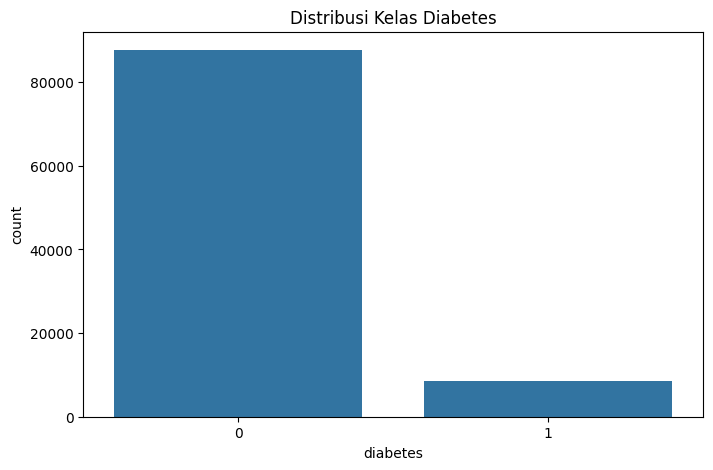

In [ ]:
#hapus duplikat
df = df.drop_duplicates()

#cek duplikat lagi
print("duplikat setelah dihapus",df.duplicated().sum())
print("Shape dataset:", df.shape)

# Cek distribusi kelas target
plt.figure(figsize=(8, 5))
sns.countplot(x='diabetes', data=df)
plt.title('Distribusi Kelas Diabetes')
plt.show()

# print("\nDistribusi kelas:")
# print(df['diabetes'].value_counts(normalize=True))

In [ ]:
# Handle data kategorikal

# encode'gender' dan 'smoking_history'
# Encode gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

# Encode smoking_history dengan ordinal encoding berdasarkan risiko
smoking_mapping = {
    'never': 0,
    'No Info': 1,
    'current': 2,
    'former': 3,
    'ever': 4,
    'not current': 5
}
df['smoking_history'] = df['smoking_history'].map(smoking_mapping)

# Pisahkan fitur dan target
# X = df.drop(['diabetes','smoking_history'], axis=1)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Split data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
# Balancing data dengan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nShape setelah SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)


Shape setelah SMOTE:
X_train_smote: (140260, 8)
y_train_smote: (140260,)


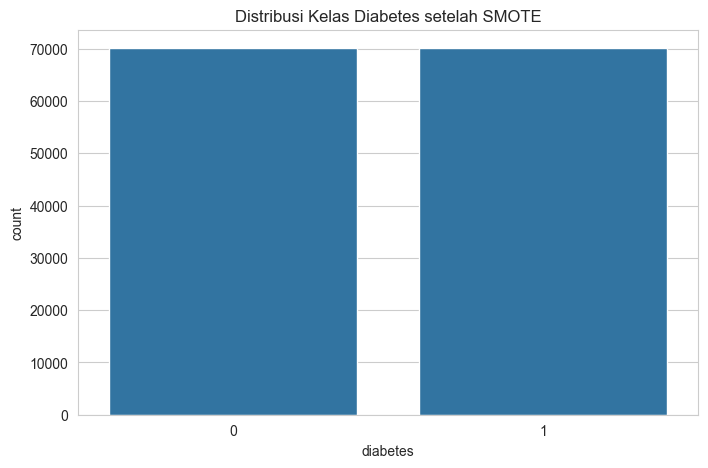

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_smote)
plt.title('Distribusi Kelas Diabetes setelah SMOTE')
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
# Random Forest + GridSearchCV (Model Optimasi)
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

preprocess = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols)],
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
])

param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 4, 8],
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_


Fitting 5 folds for each of 54 candidates, totalling 270 fits


=== Random Forest (TUNING: GridSearch + SMOTE) ===
Accuracy: 0.9585023400936038

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17534
           1       0.77      0.75      0.76      1696

    accuracy                           0.96     19230
   macro avg       0.87      0.86      0.87     19230
weighted avg       0.96      0.96      0.96     19230


Confusion Matrix:
[[17161   373]
 [  425  1271]]

=== Grid Search Hasil Terbaik (WITH SMOTE) ===
Best Parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}


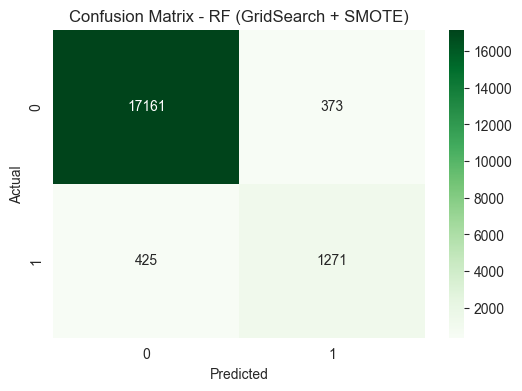

In [9]:
# Evaluasi Best Model dari GridSearch (TUNING + SMOTE)
y_pred_tuning = grid_search.best_estimator_.predict(X_test)

print("=== Random Forest (TUNING: GridSearch + SMOTE) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuning))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuning))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuning))


print("\n=== Grid Search Hasil Terbaik (WITH SMOTE) ===")
print("Best Parameters:", grid_search.best_params_)


# Confusion Matrix untuk hasil GridSearchCV (RandomForest Tuning DENGAN SMOTE)
cm_tuning = confusion_matrix(y_test, grid_search.best_estimator_.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuning, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - RF (GridSearch + SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
import pickle

best_rf = best_model.named_steps['rf']
best_preprocess = best_model.named_steps['preprocess']

best_model = Pipeline([
    ('preprocess', best_preprocess),
    ('rf', best_rf),
])

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [ ]:
# TESTING MANUAL DATA BARU
def predict_diabetes(gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level):
    
    with open('best_model.pkl', 'rb') as model_file:
        model = pickle.load(model_file)

    
    input_data = pd.DataFrame([[gender, age, hypertension, heart_disease, smoking_history,
                               bmi, HbA1c_level, blood_glucose_level]],
                             columns=['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
                                      'bmi', 'HbA1c_level', 'blood_glucose_level'])

    
    input_data['gender'] = input_data['gender'].map({'Male': 1, 'Female': 0})
    input_data['smoking_history'] = input_data['smoking_history'].map({
        'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5
    })

    
    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)

    return prediction[0], probability[0][1]


# Test dengan sample data
sample_input = {
    'gender': 'Male',
    'age': 45,
    'hypertension': 0,
    'heart_disease': 0,
    'smoking_history': 'never',
    'bmi': 28.5,
    'HbA1c_level': 6.5,
    'blood_glucose_level': 150
}

prediction, probability = predict_diabetes(**sample_input)
print("\nSample Prediction:")
print("Input Data:", sample_input)
print("Prediction (0: No Diabetes, 1: Diabetes):", prediction)
print("Probability of having diabetes: {:.2f}%".format(probability * 100))



def get_user_input():
    print("\nEnter patient information:")
    gender = input("Gender (Male/Female): ")
    age = float(input("Age: "))
    hypertension = int(input("Hypertension (0=Tidak / 1=Ya): "))
    heart_disease = int(input("Heart Disease (0=Tidak / 1=Ya): "))
    smoking_history = input("Smoking History (never/No Info/current/former/ever/not current): ")
    bmi = float(input("BMI: "))
    HbA1c_level = float(input("HbA1c Level: "))
    blood_glucose_level = float(input("Blood Glucose Level: "))

    return {
        'gender': gender,
        'age': age,
        'hypertension': hypertension,
        'heart_disease': heart_disease,
        'smoking_history': smoking_history,
        'bmi': bmi,
        'HbA1c_level': HbA1c_level,
        'blood_glucose_level': blood_glucose_level
    }



while True:
    try:
        user_input = get_user_input()
        prediction, probability = predict_diabetes(**user_input)
        print("\nHasil Prediksi:")
        print("Prediction:", 'Diabetes (1)' if prediction == 1 else 'Tidak Diabetes (0)')
        print("Probabilitas Diabetes: {:.2f}%".format(probability * 100))
    except Exception as e:
        print("Error:", e)

    if input("\nApakah ingin membuat prediksi lainnya? (yes/no): ").lower() != 'yes':
        break